# Cost and accuracy of long-term memory in DMAS — Statistical analysis

Reproduces the analysis in *Wolff & Bennati (2026)* by merging every `{prefix}{memory}_{mode}.csv` file under `experiments/results/` into a single DataFrame. Each `(framework, mode)` writes to one file; rows for multiple convs share the file and are distinguished by the `conversation_index` column. Each section maps to a table or figure in the paper.

1. Financial cost — tokens and USD per memory × regime × phase
2. Computational cost — CPU / RAM / disk / network split by cloud vs. edge × phase
2b. Responder context length per question
3. Temporal cost — wall time per memory × regime × phase
4. Response distribution — correct / wrong / IDK
5. Accuracy with 95 % Wilson confidence intervals
6. Two-proportion z-tests
6b. LLM-as-judge agreement (mean correct-vote ratio across `LLM_AS_JUDGE_SEED` calls)
7. Total cost of ownership using AWS Fargate pricing
8. Statistical Pareto-efficiency decision
9. Accuracy split by question category (per judge — keeps cat 5 visible)
9b. Accuracy table by LoCoMo category

**Methodology notes**
- LoCoMo j-score: accuracy is computed on categories 1–4 only; category 5 (adversarial) is excluded by default in §1–§8 (see [zep-papers issue #5](https://github.com/getzep/zep-papers/issues/5)).
- Each question is asked **once**. The LLM judge runs `LLM_AS_JUDGE_SEED` independent times (default 3) and the per-row `judge` column is the majority vote (>50% CORRECT ⇒ CORRECT). `judge_correct_votes / judge_n` and `judge_labels` preserve the raw ballots so §6b can report inter-judge agreement.
- Identical responder system prompt across mem0 and Graphiti — the prompt is not forked per backend (mem0/Zep dispute, May 2025; we side with the "uniform prompt across baselines" position).
- Both memory backends use loading and retrieval logic verbatim from their authors' upstream evaluation harnesses (`mem0ai/memory-benchmarks`, `getzep/zep-papers`).

In [1]:
from __future__ import annotations
import math
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('results')
JUDGE = 'judge'  # single judge column written by benchmark/app/judges.py

# LoCoMo j-score protocol scores categories 1-4 only; category 5 (adversarial)
# is excluded from accuracy aggregations (per zep-papers issue #5).
SCORED_CATEGORIES = {1, 2, 3, 4}
LOCOMO_CATEGORY_LABEL = {1: 'single-hop', 2: 'multi-hop', 3: 'temporal', 4: 'open-domain', 5: 'adversarial'}

def load_results(directory: Path = RESULTS_DIR) -> pd.DataFrame:
    """Merge every CSV under `directory` into a single DataFrame.

    The bench writes one file per `(name_prefix, memory, conv, mode)` slug
    (e.g. `test_mem0_conv0_unconstrained.csv`). All files share the same
    column schema written by `benchmark/app/results.py:COLUMNS`, so a
    plain concat produces the union view the analyses below expect.
    A legacy `results.csv` is also picked up if present.
    """
    d = Path(directory)
    if not d.exists():
        return pd.DataFrame()
    paths = sorted(p for p in d.glob('*.csv') if p.stat().st_size > 0)
    if not paths:
        return pd.DataFrame()
    frames = []
    for p in paths:
        # `question` carries free text on ask rows and an int counter on
        # load rows. Force string dtype so per-column inference doesn't
        # flip type depending on whether load or ask rows landed first.
        frames.append(pd.read_csv(p, dtype={'question': str}))
    return pd.concat(frames, ignore_index=True)

def is_unknown(answer) -> bool:
    # The responder is instructed to reply verbatim with
    # "I don't know based on the given context." when the retrieved
    # context is insufficient (see dmas/responder/app/responder_service.py).
    # We bucket those rows as UNKNOWN so they don't count as WRONG.
    return isinstance(answer, str) and "don't know based on the given context" in answer.lower()

def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    margin = z * math.sqrt((p * (1 - p) + z * z / (4 * n)) / n) / denom
    return max(0.0, center - margin), min(1.0, center + margin)

def two_proportion_ztest(k1: int, n1: int, k2: int, n2: int) -> tuple[float, float]:
    if n1 == 0 or n2 == 0:
        return (float('nan'), float('nan'))
    p1, p2 = k1 / n1, k2 / n2
    p_pool = (k1 + k2) / (n1 + n2)
    se = math.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    if se == 0:
        return (0.0, 1.0)
    z = (p1 - p2) / se
    p = 2 * (1 - 0.5 * (1 + math.erf(abs(z) / math.sqrt(2))))
    return z, p

raw = load_results()
if raw.empty:
    print('no per-experiment CSVs in', RESULTS_DIR, '— run `make experiment` first.')
    df_load = df_ask = df = pd.DataFrame()
else:
    constrained = (raw['toxic_latency'].fillna(0) > 0) | (raw['toxic_jitter'].fillna(0) > 0) | (raw['toxic_bandwidth'].fillna(0) > 0)
    raw['regime'] = constrained.map({True: 'constrained', False: 'unconstrained'})
    raw['unknown'] = raw['answer'].apply(is_unknown)
    # `category` only carries a LoCoMo question type on ask rows. Load rows
    # leave it null on purpose so the mapping doesn't claim a session
    # ordinal is e.g. "single-hop". `question_type` is therefore only
    # meaningful on ask rows.
    raw['question_type'] = raw['category'].map(LOCOMO_CATEGORY_LABEL)
    # phase=warmup carries one-time backend init cost (graphiti index
    # build, qdrant collection create) — separated so it doesn't
    # spike row #1 of the load. Excluded from accuracy and load/ask
    # totals; surfaced separately in the warmup view below.
    df_load   = raw[raw['phase'] == 'load'].copy()
    df_ask    = raw[raw['phase'] == 'ask'].copy()
    df_warmup = raw[raw['phase'] == 'warmup'].copy()
    # Default accuracy view excludes cat 5 (adversarial). §9 keeps the
    # per-category breakdown unfiltered so cat-5 behaviour stays visible.
    df = df_ask[df_ask['category'].isin(SCORED_CATEGORIES)].copy()
    print(f'rows: total={len(raw)}  load={len(df_load)}  ask={len(df_ask)}  scored(cat1-4)={len(df)}')
    print(f'memories: {sorted(raw.memory.dropna().unique())}  regimes: {sorted(raw.regime.unique())}')
raw.head()


rows: total=659  load=595  ask=60  scored(cat1-4)=60
memories: ['cognee', 'full_context', 'graphiti', 'mem0', 'rag']  regimes: ['unconstrained']


,timestamp,experiment_id,experiment_name,phase,memory,conversation_index,name_prefix,seed,question,answer,...,llm_tokens,llm_cost_usd,coordinator_asked_responder,memories_returned,top_k,search_calls,error,regime,unknown,question_type
0,2026-04-29T09:40:59.235308+00:00,b6ccc2fa45ef,test_cognee_conv0_unconstrained,warmup,cognee,0,test_,NaN,NaN,"{""status"": ""success"", ""backend"": ""cognee"", ""wa...",...,0,0.000000,NaN,NaN,NaN,NaN,NaN,unconstrained,False,NaN
1,2026-04-29T09:41:07.900913+00:00,b6ccc2fa45ef,test_cognee_conv0_unconstrained,load,cognee,0,test_,1.0,1,Caroline: Hey Mel! Good to see you! How have y...,...,2179,0.000462,NaN,NaN,NaN,NaN,NaN,unconstrained,False,NaN
2,2026-04-29T09:41:25.155622+00:00,b6ccc2fa45ef,test_cognee_conv0_unconstrained,load,cognee,0,test_,1.0,2,Melanie: Hey Caroline! Good to see you! I'm sw...,...,1190,0.000250,NaN,NaN,NaN,NaN,NaN,unconstrained,False,NaN
3,2026-04-29T09:41:32.449409+00:00,b6ccc2fa45ef,test_cognee_conv0_unconstrained,load,cognee,0,test_,1.0,3,Caroline: I went to a LGBTQ support group yest...,...,1154,0.000238,NaN,NaN,NaN,NaN,NaN,unconstrained,False,NaN
4,2026-04-29T09:41:38.607675+00:00,b6ccc2fa45ef,test_cognee_conv0_unconstrained,load,cognee,0,test_,1.0,4,"Melanie: Wow, that's cool, Caroline! What happ...",...,1166,0.000243,NaN,NaN,NaN,NaN,NaN,unconstrained,False,NaN


## 1. Financial cost — LLM tokens & USD per memory × regime × phase

Mirrors **Table 1** with both the loading and Q&A phases. Tokens are split by where the LLM is served:
- `edge_llm_*` — local ollama (qwen). Free in litellm pricing.
- `cloud_llm_*` — OpenAI passthrough.
- `llm_*` — sum.

In [2]:
if raw.empty:
    print('(empty)')
else:
    fin = (
        raw.groupby(['memory', 'regime', 'phase'])
           .agg(
               edge_tokens=('edge_llm_tokens', 'sum'),
               edge_cost=('edge_llm_cost_usd', 'sum'),
               cloud_tokens=('cloud_llm_tokens', 'sum'),
               cloud_cost=('cloud_llm_cost_usd', 'sum'),
               tokens=('llm_tokens', 'sum'),
               cost_usd=('llm_cost_usd', 'sum'),
               n=('phase', 'size'),
           )
           .reset_index()
    )
    # Drop rows where every token/cost metric is zero (warmup rows with no LLM calls).
    metric_cols = ['edge_tokens', 'edge_cost', 'cloud_tokens', 'cloud_cost', 'tokens', 'cost_usd']
    fin = fin[(fin[metric_cols] != 0).any(axis=1)].reset_index(drop=True)
    # Drop columns that are zero across every remaining row.
    keep = ['memory', 'regime', 'phase', 'n'] + [c for c in metric_cols if (fin[c] != 0).any()]
    fin = fin[keep]
    print(fin.to_string(index=False, float_format='{:.4f}'.format))

      memory        regime phase   n  edge_tokens  cloud_tokens  cloud_cost  tokens  cost_usd
      cognee unconstrained   ask  12         2543         51041      0.0081   53584    0.0081
      cognee unconstrained  load 119            0        154294      0.0332  154294    0.0332
full_context unconstrained   ask  12         2544        109888      0.0169  112432    0.0169
    graphiti unconstrained   ask  12         2543          8664      0.0016   11207    0.0016
    graphiti unconstrained  load 119            0       1342162      0.2700 1342162    0.2700
        mem0 unconstrained   ask  12         2583          6618      0.0012    9201    0.0012
        mem0 unconstrained  load 119            0        271281      0.0356  271281    0.0356
         rag unconstrained   ask  12         2543         13093      0.0023   15636    0.0023
         rag unconstrained  load 119            0          4747      0.0001    4747    0.0001


## 2. Computational cost — CPU / RAM / disk / network split by cloud vs. edge × phase

Mirrors **Table 2**. CPU is summed nanoseconds → minutes; RAM is the average bytes-in-use over each row's wall window; disk and network are summed bytes → MB. Split by phase (load vs ask).

> Edge group contains both `coordinator` (lightweight) and `ollama` (heavy local LLM). During the LOAD phase ollama is idle, so `cpu_edge` reflects coordinator overhead only. During ASK, ollama is the dominant edge consumer. Expect very different magnitudes between the two phases on the edge axis. Network is tx-only with toxiproxy excluded so each transferred byte is counted once at its sender.

In [3]:
if raw.empty:
    print('(empty)')
else:
    g = raw.groupby(['memory', 'regime', 'phase'])
    comp = pd.DataFrame({
        'cpu_cloud_min':    g['cpu_cloud_ns'].sum() / 1e9 / 60,
        'cpu_edge_min':     g['cpu_edge_ns'].sum()  / 1e9 / 60,
        # ram_*_peak_bytes is a per-call delta of memory.peak — the
        # additional working-set high-water mark induced by the call.
        # Sum (not mean) makes sense across rows because each row is
        # a non-negative delta.
        'ram_cloud_MB_peak': g['ram_cloud_peak_bytes'].sum() / 1e6,
        'ram_edge_MB_peak':  g['ram_edge_peak_bytes'].sum()  / 1e6,
        'disk_cloud_MB':    g['disk_cloud_bytes'].sum() / 1e6,
        'disk_edge_MB':     g['disk_edge_bytes'].sum()  / 1e6,
        'network_cloud_MB': g['network_cloud_bytes'].sum() / 1e6,
        'network_edge_MB':  g['network_edge_bytes'].sum()  / 1e6,
    })
    # Drop rows where every metric is exactly zero, and columns that are
    # zero everywhere.
    comp = comp[(comp != 0).any(axis=1)]
    comp = comp.loc[:, (comp != 0).any(axis=0)]
    print(comp.to_string(float_format='{:.2f}'.format))

                                   cpu_cloud_min  cpu_edge_min  ram_cloud_MB_peak  ram_edge_MB_peak  disk_cloud_MB  disk_edge_MB  network_cloud_MB  network_edge_MB
memory       regime        phase                                                                                                                                   
cognee       unconstrained ask              0.42          2.67              12.51             49.72           6.73          0.05             25.56             0.05
                           load             4.57          0.13             150.77              0.00         637.52          0.00            185.34             0.24
                           warmup           0.01          0.00              55.62              0.00           1.99          0.00              0.02             0.00
full_context unconstrained ask              0.09          2.09               1.34              8.84           5.43          0.00              3.70             0.05
                

## 2b. Responder context length per question

Mean / median `responder_context_tokens` per `(memory, regime)` on `phase=ask` rows. This is the `prompt_tokens` of the OpenAI completion that produced the final answer — i.e. the actual context length the answering LLM had to process for each question. Higher = the backend handed the responder more retrieved material to read on every question, raising both per-question latency and cost. Reading paired with §1 (cost) and §5/§9b (accuracy) makes the efficiency trade-off explicit: how many tokens does each backend force the responder to consume per correct answer?

In [4]:
if df_ask.empty or "responder_context_tokens" not in df_ask.columns:
    print("(no responder_context_tokens column — re-run the bench to populate it)")
else:
    ctx = df_ask.dropna(subset=["responder_context_tokens"]).copy()
    if ctx.empty:
        print("(no rows with responder_context_tokens recorded — older runs predate this column)")
    else:
        ctx["responder_context_tokens"] = ctx["responder_context_tokens"].astype(int)
        ctx_summary = (
            ctx.groupby(["memory", "regime"])["responder_context_tokens"]
               .agg(n="count", mean="mean", median="median",
                    p95=lambda s: s.quantile(0.95), max="max")
               .reset_index()
        )
        # Tokens per CORRECT answer — efficiency view: how many context
        # tokens the responder consumed per question that ended up scored
        # CORRECT. Lower is better. Restrict to scored categories (1-4)
        # so it lines up with the j-score numbers in §5/§6b/§9b.
        scored = ctx[ctx["category"].isin(SCORED_CATEGORIES)].copy()
        if not scored.empty:
            scored["correct"] = (scored[JUDGE] == "CORRECT").astype(int)
            eff = (
                scored.groupby(["memory", "regime"])
                      .agg(total_tokens=("responder_context_tokens", "sum"),
                           correct=("correct", "sum"),
                           asked=("correct", "size"))
                      .reset_index()
            )
            eff["tokens_per_correct"] = eff.apply(
                lambda r: (r["total_tokens"] / r["correct"]) if r["correct"] else float("nan"),
                axis=1,
            )
            eff["tokens_per_question"] = eff["total_tokens"] / eff["asked"]
            ctx_summary = ctx_summary.merge(
                eff[["memory", "regime", "tokens_per_question", "tokens_per_correct"]],
                on=["memory", "regime"], how="left",
            )
        print(ctx_summary.to_string(index=False, float_format='{:,.1f}'.format))


(no responder_context_tokens column — re-run the bench to populate it)


## 3. Temporal cost — wall time per memory × regime × phase

Mirrors **Table 3** with both the loading and Q&A phases.

      memory        regime  phase  mean_wall_s  mean_compute_s  mean_flush_s   n
      cognee unconstrained    ask         6.77            6.54          0.23  12
      cognee unconstrained   load         7.43            7.05          0.37 119
      cognee unconstrained warmup         0.97            0.77          0.21   1
full_context unconstrained    ask         7.08            6.83          0.26  12
full_context unconstrained   load         0.23            0.01          0.22 119
full_context unconstrained warmup         0.25            0.05          0.21   1
    graphiti unconstrained    ask         4.33            4.06          0.28  12
    graphiti unconstrained   load        22.04           21.71          0.32 119
    graphiti unconstrained warmup         0.32            0.12          0.21   1
        mem0 unconstrained    ask         4.49            4.22          0.27  12
        mem0 unconstrained   load         3.71            3.45          0.26 119
        mem0 unconstrained w

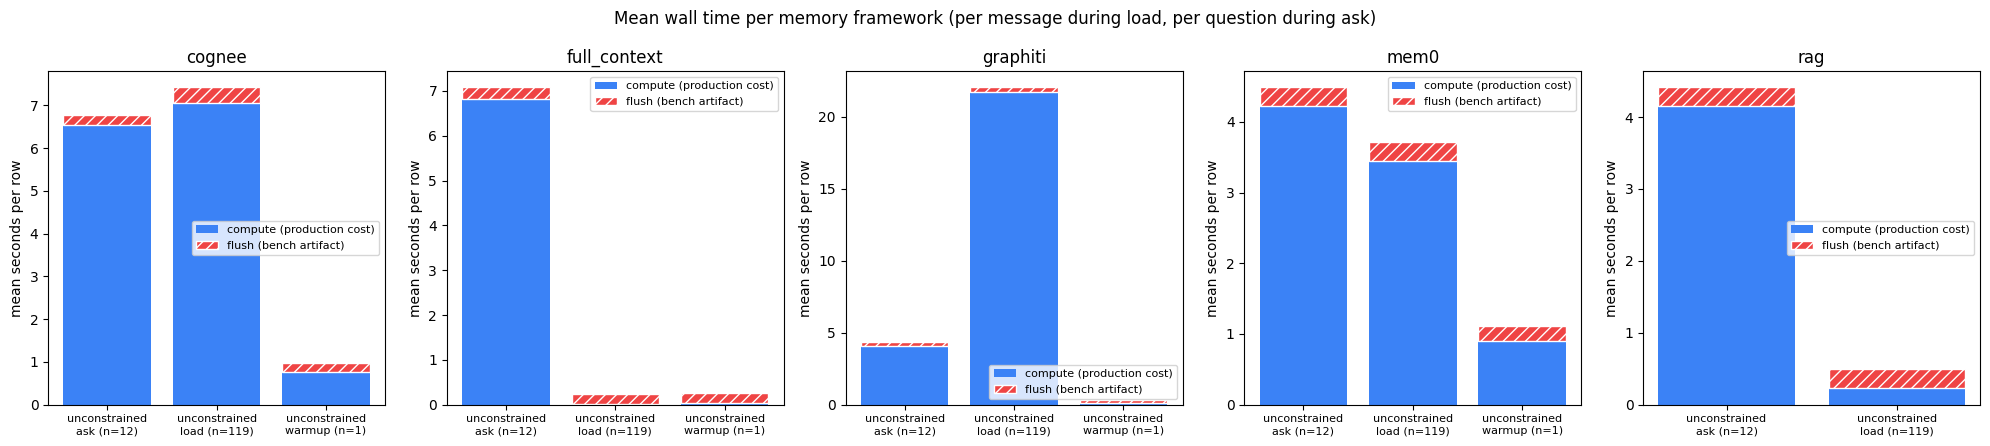

In [5]:
if raw.empty:
    print('(empty)')
else:
    # wall_ms = compute_ms + flush_ms.
    #   compute_ms is the user-facing latency a production system would pay.
    #   flush_ms is the bench-side I/O quiescence wait — instrumentation
    #   artifact added so async DB checkpoints land in the row's disk delta.
    # Report the AVERAGE per row (per message during load, per question
    # during ask), not the sum — the totals scaled with dataset size and
    # weren't comparable across phases.
    tcost = (
        raw.groupby(['memory', 'regime', 'phase'])
           .agg(mean_wall_s=('wall_ms', lambda s: s.mean() / 1000),
                mean_compute_s=('compute_ms', lambda s: s.mean() / 1000),
                mean_flush_s=('flush_ms', lambda s: s.mean() / 1000),
                n=('phase', 'size'))
           .reset_index()
    )
    # Drop rows whose mean wall time is exactly zero.
    tcost = tcost[tcost['mean_wall_s'] != 0].reset_index(drop=True)
    print(tcost.to_string(index=False, float_format='{:.2f}'.format))

    # One subplot per memory framework, each with its own y-axis so the
    # smaller backends aren't crushed by graphiti's load-phase scale.
    memories = sorted(tcost['memory'].unique())
    fig, axes = plt.subplots(1, len(memories), figsize=(4 * len(memories), 4.5),
                             sharey=False, squeeze=False)
    for ax, mem in zip(axes[0], memories):
        sub = tcost[tcost['memory'] == mem].sort_values(['regime', 'phase']).reset_index(drop=True)
        labels = [f'{r}\n{p} (n={n})' for r, p, n in zip(sub['regime'], sub['phase'], sub['n'])]
        x = range(len(sub))
        ax.bar(x, sub['mean_compute_s'], label='compute (production cost)', color='#3b82f6')
        if (sub['mean_flush_s'] != 0).any():
            ax.bar(x, sub['mean_flush_s'], bottom=sub['mean_compute_s'],
                   label='flush (bench artifact)', color='#ef4444',
                   hatch='///', edgecolor='white')
        ax.set_xticks(list(x))
        ax.set_xticklabels(labels, rotation=0, fontsize=8)
        ax.set_title(mem)
        ax.set_ylabel('mean seconds per row')
        ax.legend(fontsize=8)
    fig.suptitle('Mean wall time per memory framework (per message during load, per question during ask)')
    fig.tight_layout()
    plt.show()


## 4. Response distribution — correct / wrong / unknown

Mirrors **Table 4** and **Figure 2**. A response is UNKNOWN if the responder said “I don't know based on the given context.” (verbatim, case-insensitive). A response is CORRECT iff the primary judge labels it CORRECT; otherwise WRONG (excluding UNKNOWN).

                             n  CORRECT_pct  WRONG_pct  UNKNOWN_pct
regime        memory                                               
unconstrained cognee        12         83.3        8.3          8.3
              full_context  12         91.7        0.0          8.3
              graphiti      12         66.7       25.0          8.3
              mem0          12         58.3        0.0         41.7
              rag           12         91.7        8.3          0.0


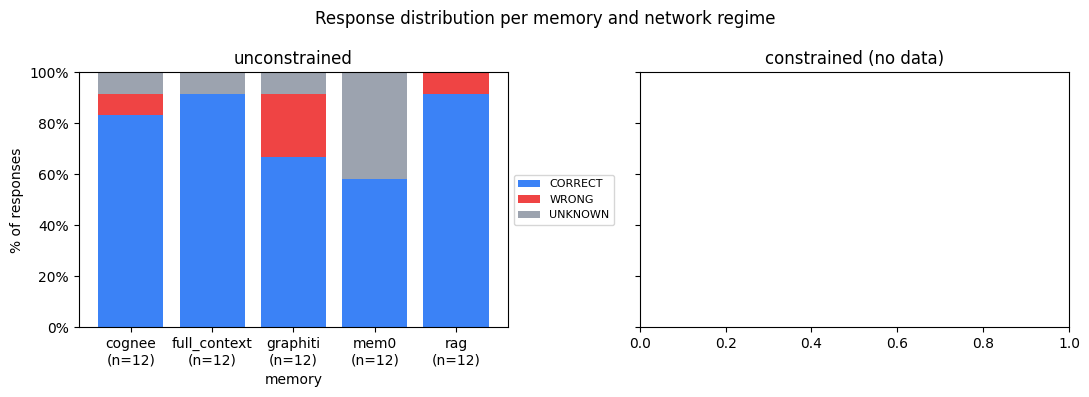

In [6]:
def classify(row):
    if row['unknown']:
        return 'UNKNOWN'
    if row[JUDGE] == 'CORRECT':
        return 'CORRECT'
    return 'WRONG'

if df.empty:
    print('(empty)')
else:
    from matplotlib.ticker import PercentFormatter
    df['outcome'] = df.apply(classify, axis=1)
    counts = (
        df.groupby(['regime', 'memory', 'outcome']).size().unstack(fill_value=0)
        .reindex(columns=['CORRECT', 'WRONG', 'UNKNOWN'], fill_value=0)
    )
    counts['n'] = counts.sum(axis=1)
    pct = counts[['CORRECT', 'WRONG', 'UNKNOWN']].div(counts['n'], axis=0) * 100
    pct.columns = ['CORRECT_pct', 'WRONG_pct', 'UNKNOWN_pct']
    table = pd.concat([counts['n'], pct], axis=1)
    nonzero_outcomes = [o for o in ['CORRECT', 'WRONG', 'UNKNOWN'] if (pct[f'{o}_pct'] > 0).any()]
    keep_cols = ['n'] + [f'{o}_pct' for o in nonzero_outcomes]
    print(table[keep_cols].to_string(float_format='{:.1f}'.format))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    palette = {'CORRECT': '#3b82f6', 'WRONG': '#ef4444', 'UNKNOWN': '#9ca3af'}
    for ax, regime in zip(axes, ['unconstrained', 'constrained']):
        sub = pct.xs(regime, level='regime') if regime in pct.index.get_level_values(0) else pd.DataFrame()
        if sub.empty:
            ax.set_title(f'{regime} (no data)')
            continue
        n_per_memory = counts.xs(regime, level='regime')['n']
        # Show the question count (n) under each memory label so the
        # denominator behind the percentages is always visible.
        x_labels = [f'{m}\n(n={int(n_per_memory.loc[m])})' for m in sub.index]
        bottom = pd.Series(0.0, index=sub.index)
        for outcome in nonzero_outcomes:
            vals = sub[f'{outcome}_pct']
            if (vals == 0).all():
                continue
            ax.bar(x_labels, vals, bottom=bottom, label=outcome, color=palette[outcome])
            bottom = bottom + vals
        ax.set_title(regime)
        ax.set_ylabel('% of responses')
        ax.set_xlabel('memory')
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
    fig.suptitle('Response distribution per memory and network regime')
    plt.tight_layout(); plt.show()

## 5. Accuracy with 95 % Wilson confidence intervals

Mirrors **Table 5**. Closed-form Wilson interval, no scipy/statsmodels dependency.

In [7]:
if df.empty:
    print('(empty)')
else:
    rows = []
    for (memory, regime), sub in df.groupby(['memory', 'regime']):
        n = len(sub)
        k = int((sub[JUDGE] == 'CORRECT').sum())
        lo, hi = wilson_ci(k, n)
        rows.append({'memory': memory, 'regime': regime, 'n': n, 'correct': k,
                     'accuracy': k / n if n else 0.0, 'ci_lo': lo, 'ci_hi': hi})
    tab5 = pd.DataFrame(rows).sort_values(['memory', 'regime']).reset_index(drop=True)
    print(tab5.to_string(index=False, float_format='{:.3f}'.format))

      memory        regime  n  correct  accuracy  ci_lo  ci_hi
      cognee unconstrained 12       10     0.833  0.552  0.953
full_context unconstrained 12       11     0.917  0.646  0.985
    graphiti unconstrained 12        8     0.667  0.391  0.862
        mem0 unconstrained 12        7     0.583  0.320  0.807
         rag unconstrained 12       11     0.917  0.646  0.985


## 6. Two-proportion z-tests

Mirrors **Table 6**. α = 0.05. Closed-form pooled-variance two-sided test.

In [8]:
if df.empty:
    print('(empty)')
else:
    def kn(memory, regime):
        sub = df[(df['memory'] == memory) & (df['regime'] == regime)]
        return int((sub[JUDGE] == 'CORRECT').sum()), len(sub)

    comparisons = []
    pairs = [
        ('graphiti vs mem0 (unconstrained)', ('graphiti', 'unconstrained'), ('mem0', 'unconstrained')),
        ('graphiti vs mem0 (constrained)',   ('graphiti', 'constrained'),   ('mem0', 'constrained')),
        ('graphiti: unconstrained vs constrained', ('graphiti', 'unconstrained'), ('graphiti', 'constrained')),
        ('mem0: unconstrained vs constrained',     ('mem0', 'unconstrained'),     ('mem0', 'constrained')),
    ]
    for label, a, b in pairs:
        k1, n1 = kn(*a); k2, n2 = kn(*b)
        # Skip comparisons where either side has no data (n=0); those produce
        # NaN z/p that are noise rather than information.
        if n1 == 0 or n2 == 0:
            continue
        z, p = two_proportion_ztest(k1, n1, k2, n2)
        comparisons.append({'comparison': label, 'k1': k1, 'n1': n1, 'k2': k2, 'n2': n2,
                             'z_stat': z, 'p_value': p, 'significant_alpha_0.05': bool(p < 0.05)})
    if not comparisons:
        print('(no pairs with data on both sides)')
    else:
        tab6 = pd.DataFrame(comparisons)
        print(tab6.to_string(index=False, float_format='{:.4f}'.format))

                      comparison  k1  n1  k2  n2  z_stat  p_value  significant_alpha_0.05
graphiti vs mem0 (unconstrained)   8  12   7  12  0.4216   0.6733                   False


## 6b. LLM-as-judge agreement

With the new protocol there is exactly one ask per question; the variability source is the judge, not the responder. For each `(memory, regime)` we report the mean of `judge_correct_votes / judge_n` across all scored questions — i.e. how often the panel of judges agreed the answer was correct, on a 0–1 scale. A row at 1.0 means every judge agreed CORRECT on every question; 0.0 means every judge said WRONG. Spread between this and §5's accuracy reflects how often the majority vote flipped a split panel.

In [9]:
if df.empty:
    print('(empty)')
elif "judge_correct_votes" not in df.columns or "judge_n" not in df.columns:
    print('(no judge_correct_votes / judge_n columns — older runs predate the LLM_AS_JUDGE_SEED protocol)')
else:
    panel = df.dropna(subset=["judge_correct_votes", "judge_n"]).copy()
    panel = panel[panel["judge_n"].astype(float) > 0]
    if panel.empty:
        print('(no rows with judge votes recorded)')
    else:
        panel["agreement"] = panel["judge_correct_votes"].astype(float) / panel["judge_n"].astype(float)
        summary = (
            panel.groupby(["memory", "regime"])
                 .agg(n_questions=("agreement", "size"),
                      mean_agreement=("agreement", "mean"),
                      majority_correct=("judge", lambda s: (s == "CORRECT").mean()),
                      judge_n=("judge_n", "max"))
                 .reset_index()
        )
        summary["mean_agreement_pct"] = summary["mean_agreement"] * 100
        summary["majority_correct_pct"] = summary["majority_correct"] * 100
        cols = ["memory", "regime", "judge_n", "n_questions", "mean_agreement_pct", "majority_correct_pct"]
        print(summary[cols].to_string(index=False, float_format='{:.2f}'.format))


(no judge_correct_votes / judge_n columns — older runs predate the LLM_AS_JUDGE_SEED protocol)


## 7. Total cost of ownership (AWS Fargate, us-east-1)

Mirrors **Section 4.1 / Figure 3**. Pricing:

- Compute: \$0.04048 / vCPU-hour
- RAM: \$0.004445 / GB-hour
- Storage (EBS gp3): \$0.000109 / GB-hour
- Network (egress): \$0.09 / GB

Cost breakdown (USD) per memory × regime × phase, grouped by resource type:
                                   cost_cpu  cost_ram  cost_disk  cost_net  cost_llm    total
memory       regime        phase                                                             
cognee       unconstrained ask     0.002087  0.000001   0.000000  0.002305  0.008077 0.012470
                           load    0.003175  0.000002   0.000000  0.016702  0.033206 0.053085
                           warmup  0.000004  0.000000   0.000000  0.000002  0.000000 0.000006
full_context unconstrained ask     0.001470  0.000000   0.000000  0.000338  0.016860 0.018667
                           load    0.000032  0.000000   0.000000  0.000044  0.000000 0.000076
                           warmup  0.000000  0.000000   0.000000  0.000000  0.000000 0.000000
graphiti     unconstrained ask     0.001673  0.000000   0.000000  0.001028  0.001581 0.004282
                           load    0.003549  0.000004   0.000000  0.043224  0.

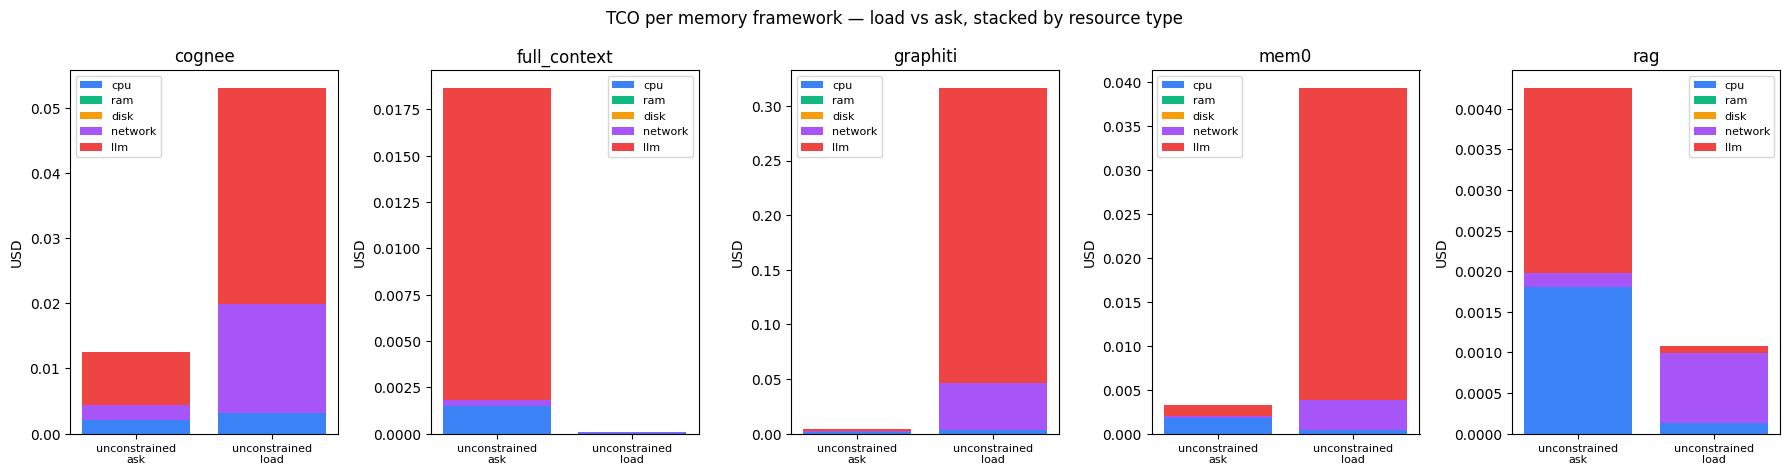

In [10]:
VCPU_PER_HOUR  = 0.04048
RAM_GB_HOUR    = 0.004445
DISK_GB_HOUR   = 0.000109
NET_PER_GB     = 0.09

if raw.empty:
    print('(empty)')
else:
    # Per-row resource cost across BOTH phases (load + ask).
    work = raw.copy()
    # Use compute_ms (production-equivalent latency) for the GB-hour
    # cost multiplier — flush_ms is bench-introduced quiescence wait that
    # a real customer would never pay.
    compute_h = work['compute_ms'] / 1000 / 3600
    for grp in ('edge', 'cloud'):
        cpu_h  = work[f'cpu_{grp}_ns'] / 1e9 / 3600
        ram_gb = work[f'ram_{grp}_peak_bytes'] / 1e9
        disk_gb = work[f'disk_{grp}_bytes'] / 1e9
        net_gb = work[f'network_{grp}_bytes'] / 1e9
        work[f'cost_cpu_{grp}']  = cpu_h * VCPU_PER_HOUR
        work[f'cost_ram_{grp}']  = ram_gb * compute_h * RAM_GB_HOUR
        work[f'cost_disk_{grp}'] = disk_gb * compute_h * DISK_GB_HOUR
        work[f'cost_net_{grp}']  = net_gb * NET_PER_GB
    work['cost_llm_edge']  = work['edge_llm_cost_usd'].fillna(0)
    work['cost_llm_cloud'] = work['cloud_llm_cost_usd'].fillna(0)

    # Collapse the edge/cloud split into per-resource totals — the chart
    # below is "what resource type drives cost per phase per backend".
    for kind in ('cpu', 'ram', 'disk', 'net', 'llm'):
        work[f'cost_{kind}'] = work[f'cost_{kind}_edge'] + work[f'cost_{kind}_cloud']

    cost_cols = [f'cost_{k}' for k in ('cpu', 'ram', 'disk', 'net', 'llm')]
    tco_full = work.groupby(['memory', 'regime', 'phase'])[cost_cols].sum()
    tco_full['total'] = tco_full[cost_cols].sum(axis=1)
    # Drop phases whose total cost is exactly zero, and resource columns
    # that are zero across every remaining row.
    tco = tco_full[tco_full['total'] != 0]
    nonzero_cost_cols = [c for c in cost_cols if (tco[c] != 0).any()]
    tco = tco[nonzero_cost_cols + ['total']]
    print('Cost breakdown (USD) per memory × regime × phase, grouped by resource type:')
    print(tco.to_string(float_format='{:.6f}'.format))

    # Flat TCO per (memory, regime) for §8.
    tco_flat = tco.groupby(['memory', 'regime'])['total'].sum().to_frame('total')

    # One subplot per memory framework. Each subplot shows one bar per
    # (regime, phase) restricted to load + ask, with the bar stacked by
    # resource type (cpu / ram / disk / net / llm) so you can read the
    # cost composition vertically.
    plot_phases = [p for p in ('load', 'ask') if p in tco.index.get_level_values('phase')]
    if not plot_phases:
        print('(no load/ask cost data)')
    else:
        memories = sorted(tco.index.get_level_values('memory').unique())
        fig, axes = plt.subplots(1, len(memories), figsize=(3.6 * len(memories), 4.8),
                                 sharey=False, squeeze=False)
        resource_palette = {
            'cost_cpu':  '#3b82f6',
            'cost_ram':  '#10b981',
            'cost_disk': '#f59e0b',
            'cost_net':  '#a855f7',
            'cost_llm':  '#ef4444',
        }
        resource_label = {'cost_cpu': 'cpu', 'cost_ram': 'ram', 'cost_disk': 'disk',
                          'cost_net': 'network', 'cost_llm': 'llm'}
        for ax, mem in zip(axes[0], memories):
            sub = tco.xs(mem, level='memory')
            sub = sub[sub.index.get_level_values('phase').isin(plot_phases)]
            sub = sub.sort_index()
            if sub.empty:
                ax.set_title(f'{mem} (no data)'); continue
            x_labels = [f'{r}\n{p}' for r, p in sub.index]
            x = list(range(len(sub)))
            bottom = [0.0] * len(sub)
            for col in nonzero_cost_cols:
                vals = sub[col].tolist()
                if all(v == 0 for v in vals):
                    continue
                ax.bar(x, vals, bottom=bottom, label=resource_label[col],
                       color=resource_palette[col])
                bottom = [b + v for b, v in zip(bottom, vals)]
            ax.set_xticks(x)
            ax.set_xticklabels(x_labels, rotation=0, fontsize=8)
            ax.set_title(mem)
            ax.set_ylabel('USD')
            ax.legend(fontsize=8)
        fig.suptitle('TCO per memory framework — load vs ask, stacked by resource type')
        fig.tight_layout()
        plt.show()

## 8. Statistical Pareto-efficiency decision

Per **Section 4.2**: a system $S_A$ strictly dominates $S_B$ iff
1. $C(S_A) < C(S_B)$, AND
2. The accuracy gap $A(S_B) - A(S_A)$ is *not* statistically significant.

Under that definition the optimization collapses to cost-minimization whenever the z-test in §6 fails to reject the null.

In [11]:
if df.empty:
    print('(empty)')
else:
    for regime in ['unconstrained', 'constrained']:
        if regime not in tco_flat.index.get_level_values('regime'):
            continue
        sub_cost = tco_flat.xs(regime, level='regime')['total']
        if {'mem0', 'graphiti'} - set(sub_cost.index):
            print(f'[{regime}] need both mem0 and graphiti rows for the comparison'); continue
        cost_mem0 = sub_cost.loc['mem0']
        cost_graphiti = sub_cost.loc['graphiti']
        def kn(memory, regime):
            sub = df[(df['memory'] == memory) & (df['regime'] == regime)]
            return int((sub[JUDGE] == 'CORRECT').sum()), len(sub)
        k_m, n_m = kn('mem0', regime); k_g, n_g = kn('graphiti', regime)
        z, p = two_proportion_ztest(k_g, n_g, k_m, n_m)
        statistically_equivalent = p >= 0.05
        print(f'[{regime}]  TCO mem0 = ${cost_mem0:.4f}   TCO graphiti = ${cost_graphiti:.4f}   z={z:.3f}, p={p:.4f}')
        if statistically_equivalent and cost_mem0 < cost_graphiti:
            print(f'           ⇒ mem0 is Pareto-dominant (cheaper, accuracy gap not significant).')
        elif statistically_equivalent and cost_graphiti < cost_mem0:
            print(f'           ⇒ graphiti is Pareto-dominant (cheaper, accuracy gap not significant).')
        else:
            print('           ⇒ no strict dominance: the accuracy gap IS statistically significant; this is a real trade-off.')

[unconstrained]  TCO mem0 = $0.0426   TCO graphiti = $0.3211   z=0.422, p=0.6733
           ⇒ mem0 is Pareto-dominant (cheaper, accuracy gap not significant).


## 9. Accuracy split by question category × judge

Per-judge view (mem0 / zep / dmas) of accuracy across LoCoMo categories × regime.

In [12]:
if df_ask.empty:
    print('(empty)')
else:
    # Use the unfiltered ask phase here so cat 5 stays visible.
    out = (
        df_ask.groupby(['memory', 'question_type', 'regime'])[JUDGE]
              .apply(lambda s: (s == 'CORRECT').mean())
              .rename('accuracy').reset_index()
    )
    if out.empty:
        print('(no rows)')
    else:
        pivot = out.pivot_table(index=['memory', 'question_type'], columns='regime', values='accuracy')
        print(pivot.to_string(float_format='{:.3f}'.format))

regime                      unconstrained
memory       question_type               
cognee       multi-hop              0.333
             open-domain            1.000
             single-hop             1.000
             temporal               1.000
full_context multi-hop              1.000
             open-domain            1.000
             single-hop             1.000
             temporal               0.667
graphiti     multi-hop              0.333
             open-domain            1.000
             single-hop             0.667
             temporal               0.667
mem0         multi-hop              0.333
             open-domain            1.000
             single-hop             0.667
             temporal               0.333
rag          multi-hop              1.000
             open-domain            1.000
             single-hop             0.667
             temporal               1.000


### 9b. Accuracy table by LoCoMo category

Same data as §9 but pivoted for readability: rows = `(memory, regime)`, columns = LoCoMo categories. Each cell shows `k/n (acc%)`. The `overall (1-4)` column reproduces the j-score (cat 1-4 only) and matches §5/§6b.

In [13]:
if df_ask.empty:
    print('(empty)')
else:
    cat_order = [1, 2, 3, 4, 5]
    cat_cols = [LOCOMO_CATEGORY_LABEL[c] for c in cat_order]

    def fmt(k, n):
        if n == 0:
            return '-'
        return f'{k}/{n} ({100 * k / n:.0f}%)'

    rows = []
    for (memory, regime), sub in df_ask.groupby(['memory', 'regime']):
        row = {'memory': memory, 'regime': regime}
        for c in cat_order:
            cat_sub = sub[sub['category'] == c]
            n = len(cat_sub)
            k = int((cat_sub[JUDGE] == 'CORRECT').sum())
            row[LOCOMO_CATEGORY_LABEL[c]] = fmt(k, n)
        scored = sub[sub['category'].isin(SCORED_CATEGORIES)]
        n_all = len(scored)
        k_all = int((scored[JUDGE] == 'CORRECT').sum())
        row['overall (1-4)'] = fmt(k_all, n_all)
        rows.append(row)
    cat_table = pd.DataFrame(rows).set_index(['memory', 'regime'])[cat_cols + ['overall (1-4)']]
    print(cat_table.to_string())


                            single-hop   multi-hop    temporal open-domain adversarial overall (1-4)
memory       regime                                                                                 
cognee       unconstrained  3/3 (100%)   1/3 (33%)  3/3 (100%)  3/3 (100%)           -   10/12 (83%)
full_context unconstrained  3/3 (100%)  3/3 (100%)   2/3 (67%)  3/3 (100%)           -   11/12 (92%)
graphiti     unconstrained   2/3 (67%)   1/3 (33%)   2/3 (67%)  3/3 (100%)           -    8/12 (67%)
mem0         unconstrained   2/3 (67%)   1/3 (33%)   1/3 (33%)  3/3 (100%)           -    7/12 (58%)
rag          unconstrained   2/3 (67%)  3/3 (100%)  3/3 (100%)  3/3 (100%)           -   11/12 (92%)


## Appendix — column glossary

Per-experiment CSV schema (one file per `(prefix, memory, conv, mode)` slug). Three phases:
- `phase=warmup` — one row per `(memory, conv, mode)` leg, written immediately after the pre-leg reset. Captures one-time backend init (graphiti `build_indices_and_constraints`, qdrant collection creation) so it doesn't get folded into row #1 of the load. `question`, `seed`, `category`, `judge*` are null.
- `phase=load` — one row per memory persisted (loaded). `seed` holds the **session number** (1..N), `question` holds the **global message counter** (1..M) within the conv. `category` is null.
- `phase=ask` — one row per Q&A. `category` holds the LoCoMo **question category** (1=single-hop, 2=multi-hop, 3=temporal, 4=open-domain, 5=adversarial), `question` holds the prompt text. `seed` is null on ask rows; each question is asked exactly once. `judge_n` / `judge_correct_votes` / `judge_labels` capture the LLM-as-judge panel (default 3 calls), and `judge` is the majority vote.

Timing (no rounding, all milliseconds):

| Column        | Meaning                                                                 |
| ------------- | ----------------------------------------------------------------------- |
| `wall_ms`     | `compute_ms + flush_ms` — total bench-measured time for the row.        |
| `compute_ms`  | `t_call_start` → HTTP response returned. **The user-facing latency a production system would pay.** |
| `flush_ms`    | Bench-side I/O quiescence wait we add *after* the response so async DB checkpoints (Neo4j) land in this row's `disk_cloud_bytes`. **Instrumentation artifact**, not a real cost. |

Resource counters (kernel-direct, no scrape interval):

| Column                    | Meaning                                                                 |
| ------------------------- | ----------------------------------------------------------------------- |
| `cpu_edge_ns`             | Cumulative CPU time consumed by edge containers during this call (ns). Edge = `coordinator`, `ollama`. |
| `cpu_cloud_ns`            | Same for cloud containers (`benchmark`, `memory`, `qdrant`, `neo4j`, `litellm`, `responder`, `toxiproxy`). |
| `ram_edge_peak_bytes`     | Per-call delta of edge group's `memory.peak` — additional working-set high-water mark induced by the call. Non-negative. |
| `ram_cloud_peak_bytes`    | Same for cloud group.                                                   |
| `disk_edge_bytes`         | Edge group's blkio read+write delta during the call (cgroup `io.stat`). |
| `disk_cloud_bytes`        | Same for cloud. Captures Neo4j async-checkpoint writes thanks to `flush_ms` quiescence wait. |
| `network_edge_bytes`      | TX-only bytes from edge containers (each byte counted once at sender; toxiproxy excluded). |
| `network_cloud_bytes`     | Same for cloud.                                                         |

LLM tokens (litellm `/metrics`, split by model name into edge vs cloud):

| Column               | Meaning                                                                 |
| -------------------- | ----------------------------------------------------------------------- |
| `edge_llm_tokens`    | Tokens served by ollama (`local-slm` alias → `qwen2.5:3b-instruct-q4_K_M`). Free in litellm pricing. |
| `edge_llm_cost_usd`  | USD cost of edge LLM tokens (≈ 0).                                      |
| `cloud_llm_tokens`   | Tokens through OpenAI passthrough (`gpt-4o-mini`, `text-embedding-3-small`, ...). |
| `cloud_llm_cost_usd` | USD cost of cloud LLM tokens — the real bill.                           |
| `llm_tokens`         | `edge + cloud`.                                                         |
| `llm_cost_usd`       | `edge + cloud`.                                                         |

Resource counters are read directly from kernel cgroup pseudo-files and litellm's `/metrics` endpoint — every snapshot reflects the moment of the read, no TSDB middleman.


Responder context (per-`phase=ask` row, populated by responder→coordinator→benchmark plumbing):

| Column                       | Meaning                                                                 |
| ---------------------------- | ----------------------------------------------------------------------- |
| `responder_context_tokens`   | `prompt_tokens` of the OpenAI completion that produced the final answer — the actual context length the answering LLM consumed for this question. Used in §2b to compute `tokens_per_question` and `tokens_per_correct`. Null on warmup/load rows and on ask rows that errored before the final completion. |


LLM-as-judge consensus columns (per `phase=ask` row):

| Column                  | Meaning                                                                 |
| ----------------------- | ----------------------------------------------------------------------- |
| `judge_n`               | Number of independent judge calls per row, set by `LLM_AS_JUDGE_SEED` on the request (default 3). |
| `judge_correct_votes`   | Count of those calls that returned CORRECT.                             |
| `judge_labels`          | Pipe-separated labels in call order, e.g. `"CORRECT|WRONG|CORRECT"`. |
| `judge`                 | Majority-vote final verdict (CORRECT iff >50% of calls returned CORRECT). |
